# **Eliminación de columnas innecesarias para la creacion de modelos**

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('TelecomX_Simplified_Data.csv')

# 2. Eliminar la columna 'Cuentas_Diarias' para evitar problemas en el modelo (multicolinealidad)
if 'Cuentas_Diarias' in df.columns:
    df_ml = df.drop(columns=['Cuentas_Diarias'])
else:
    df_ml = df.copy()

# 3. Codificación de variables categóricas (One-Hot Encoding)
# Transformamos 'Contrato' y 'Metodo_Pago' en columnas de 0s y 1s.
df_ml = pd.get_dummies(df_ml, columns=['Contrato', 'Metodo_Pago'], dtype=int, drop_first=True)

# 4. Análisis de Correlación
# Calculamos cómo se relaciona cada variable matemáticamente con la 'Evasion'
correlacion = df_ml.corr()['Evasion'].sort_values(ascending=False)

print("--- Correlación Matemática con la Evasión (Churn) ---")
print(correlacion)



--- Correlación Matemática con la Evasión (Churn) ---
Evasion                               1.000000
Contrato_Mes a mes                    0.405103
Cargo_Mensual                         0.193356
Metodo_Pago_Cheque por correo        -0.091683
Metodo_Pago_Transferencia bancaria   -0.117937
Metodo_Pago_Tarjeta de credito       -0.134302
Soporte_Tecnico                      -0.164674
Seguridad_En_Linea                   -0.171226
Contrato_Un año                      -0.177820
Permanencia_Meses                    -0.352229
Name: Evasion, dtype: float64


# **` Verificación de la Proporción de Cancelación (Churn)`**

In [23]:


# Calcular frecuencias
conteo = df['Evasion'].value_counts()
proporcion = (df['Evasion'].value_counts(normalize=True) * 100).round(2)

print("--- Frecuencia Absoluta ---")
print(conteo)
print("\n--- Proporción (%) ---")
print(proporcion)

--- Frecuencia Absoluta ---
Evasion
0    5174
1    1869
Name: count, dtype: int64

--- Proporción (%) ---
Evasion
0    73.46
1    26.54
Name: proportion, dtype: float64


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separar las características (X) de la variable objetivo que queremos predecir (y)
X = df_ml.drop(columns=['Evasion'])
y = df_ml['Evasion']

# 2. Dividir en Entrenamiento (80%) y Prueba (20%)
# El parámetro "stratify=y" es MAGIA: asegura que ese 73/26% de desbalance
# se mantenga exactamente igual tanto en el grupo de estudio como en el de examen.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Escalar (Normalizar) las variables numéricas
scaler = StandardScaler()
columnas_numericas = ['Permanencia_Meses', 'Cargo_Mensual']

# Hacemos copias para no alterar los datos originales accidentalmente
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# El modelo "aprende" la escala solo con los datos de entrenamiento (fit_transform)
X_train_scaled[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])

# Y luego aplica esa misma regla a los datos de prueba (transform)
X_test_scaled[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

print(f"--- Datos listos para Machine Learning ---")
print(f"Cantidad de clientes para Entrenar: {X_train_scaled.shape[0]}")
print(f"Cantidad de clientes para Evaluar: {X_test_scaled.shape[0]}")
print(f"Total de variables predictoras: {X_train_scaled.shape[1]}")

--- Datos listos para Machine Learning ---
Cantidad de clientes para Entrenar: 5634
Cantidad de clientes para Evaluar: 1409
Total de variables predictoras: 9


# **SMOTE (Técnica de Sobremuestreo de Minorías Sintéticas)**

SMOTE utiliza la geometría matemática para inventar clientes sintéticos que tienen características muy realistas, rellenando el vacío de tu clase minoritaria hasta igualar la balanza.


In [25]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Inicializar el algoritmo SMOTE
smote = SMOTE(random_state=42)

# 2. Aplicar SMOTE exclusivamente a los datos de ENTRENAMIENTO
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# 3. Comprobar la magia matemática
print("--- Antes del Balanceo (y_train) ---")
print(y_train.value_counts())

print("\n--- Después de SMOTE (y_train_bal) ---")
print(y_train_bal.value_counts())

print(f"\n¡Listo! Ahora tienes {X_train_bal.shape[0]} registros perfectamente equilibrados para entrenar.")

--- Antes del Balanceo (y_train) ---
Evasion
0    4139
1    1495
Name: count, dtype: int64

--- Después de SMOTE (y_train_bal) ---
Evasion
0    4139
1    4139
Name: count, dtype: int64

¡Listo! Ahora tienes 8278 registros perfectamente equilibrados para entrenar.


# Análisis de **Correlación**

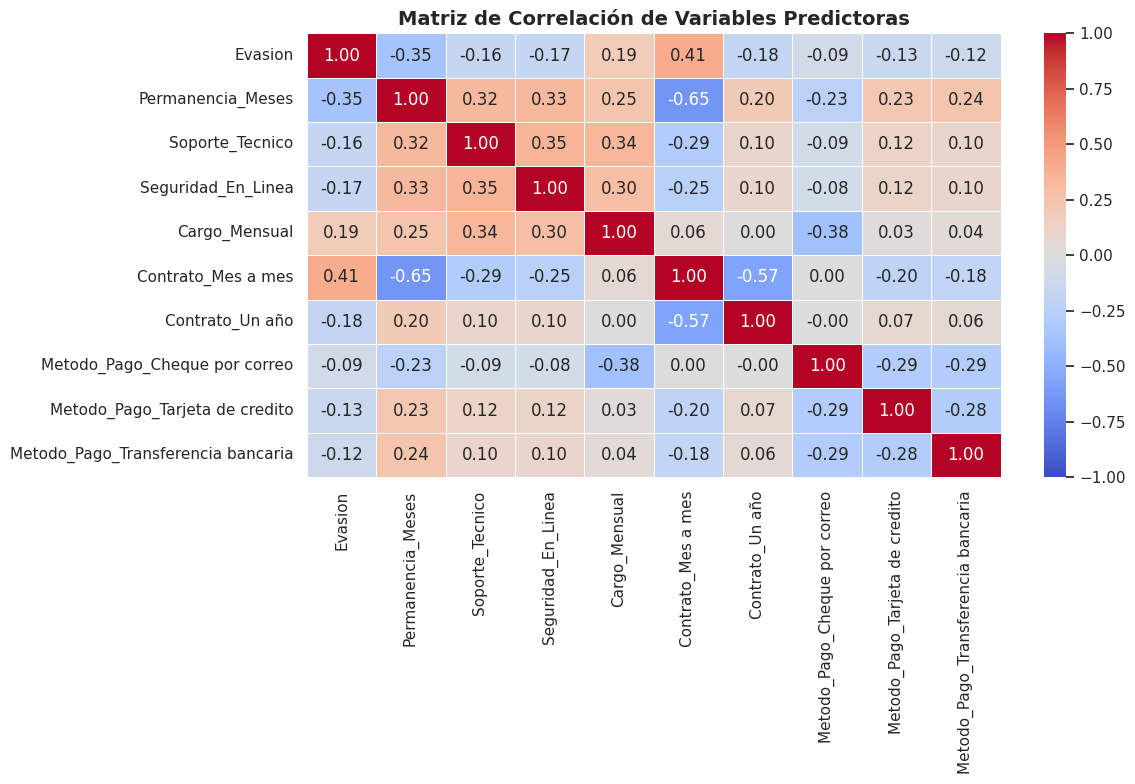

--- Correlación Matemática con la Evasión (Churn) ---
Evasion                               1.000000
Contrato_Mes a mes                    0.405103
Cargo_Mensual                         0.193356
Metodo_Pago_Cheque por correo        -0.091683
Metodo_Pago_Transferencia bancaria   -0.117937
Metodo_Pago_Tarjeta de credito       -0.134302
Soporte_Tecnico                      -0.164674
Seguridad_En_Linea                   -0.171226
Contrato_Un año                      -0.177820
Permanencia_Meses                    -0.352229
Name: Evasion, dtype: float64


In [26]:


# 1. Cargar los datos
df = pd.read_csv('TelecomX_Simplified_Data.csv')

# Eliminamos 'Cuentas_Diarias' porque es matemáticamente idéntica a 'Cargo_Mensual' / 30
if 'Cuentas_Diarias' in df.columns:
    df = df.drop(columns=['Cuentas_Diarias'])

# 2. Codificar las variables de texto a numéricas (One-Hot Encoding)
# Esto nos permite ver la correlación de "Contrato_Mes a mes" y los métodos de pago.
df_numeric = pd.get_dummies(df, columns=['Contrato', 'Metodo_Pago'], dtype=int, drop_first=True)

# 3. Calcular la matriz de correlación completa
corr_matrix = df_numeric.corr()

# 4. Crear el Heatmap (Mapa de Calor)
plt.figure(figsize=(12, 8))
# cmap='coolwarm' pone en rojo las correlaciones positivas y en azul las negativas
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Variables Predictoras', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# 5. Imprimir la lista ordenada de correlaciones exclusivamente con "Evasion"
print("--- Correlación Matemática con la Evasión (Churn) ---")
print(corr_matrix['Evasion'].sort_values(ascending=False))

# Análisis **Dirigido**

Tiempo de contrato × Cancelación

Gasto total × Cancelación

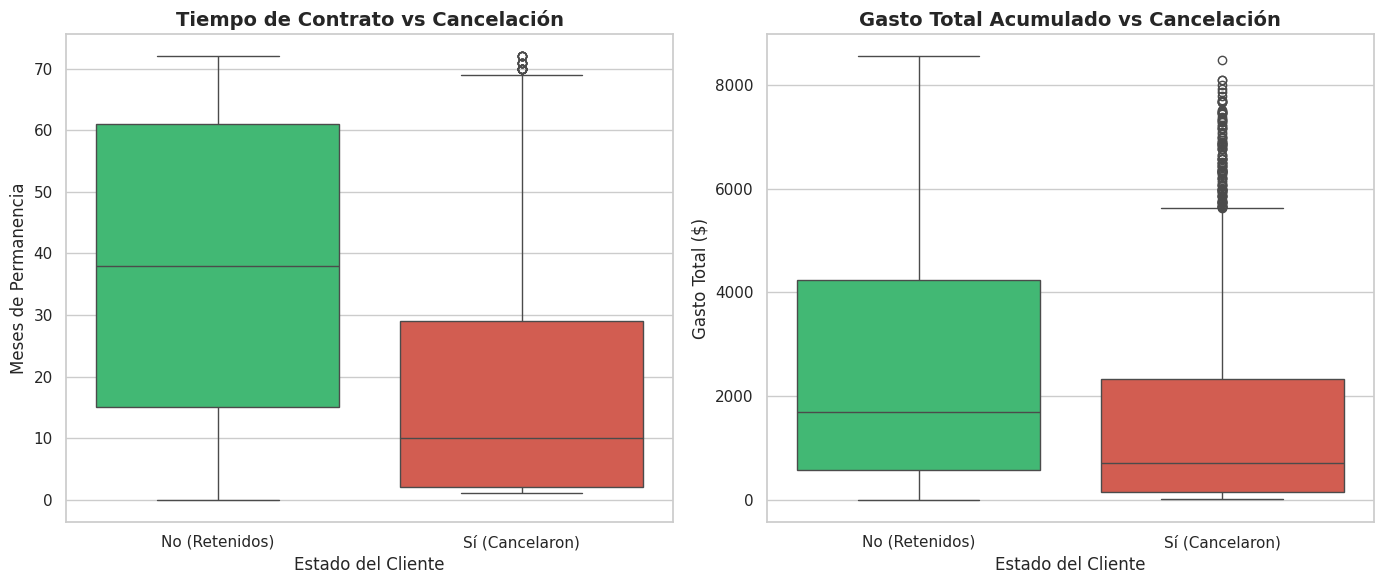

--- Medianas por Grupo ---
                 Permanencia_Meses  Gasto_Total
Evasion_Etiq                                   
No (Retenidos)                38.0     1687.125
Sí (Cancelaron)               10.0      700.000


In [27]:

# 1. Cargar los datos simplificados
df = pd.read_csv('TelecomX_Simplified_Data.csv')

# Crear etiquetas legibles para la gráfica (0: Retenidos, 1: Cancelaron)
df['Evasion_Etiq'] = df['Evasion'].map({0: 'No (Retenidos)', 1: 'Sí (Cancelaron)'})

# 2. Reconstruir un estimado de "Gasto Total" para este análisis específico
df['Gasto_Total'] = df['Permanencia_Meses'] * df['Cargo_Mensual']

# 3. Configurar el lienzo de gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico 1: Tiempo de Contrato vs Cancelación ---
sns.boxplot(data=df, x='Evasion_Etiq', y='Permanencia_Meses', hue='Evasion_Etiq',
            ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Tiempo de Contrato vs Cancelación', fontsize=14, weight='bold')
axes[0].set_xlabel('Estado del Cliente', fontsize=12)
axes[0].set_ylabel('Meses de Permanencia', fontsize=12)

# --- Gráfico 2: Gasto Total vs Cancelación ---
sns.boxplot(data=df, x='Evasion_Etiq', y='Gasto_Total', hue='Evasion_Etiq',
            ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Gasto Total Acumulado vs Cancelación', fontsize=14, weight='bold')
axes[1].set_xlabel('Estado del Cliente', fontsize=12)
axes[1].set_ylabel('Gasto Total ($)', fontsize=12)

plt.tight_layout()
plt.show()

# Imprimir las medianas exactas para tu reporte
print("--- Medianas por Grupo ---")
print(df.groupby('Evasion_Etiq')[['Permanencia_Meses', 'Gasto_Total']].median())

🧠 ¿Qué nos dicen estos gráficos (Boxplots)?
Tiempo de contrato × Cancelación (Gráfico Izquierdo):

Es evidente que **los clientes que cancelan** *(la caja roja)* tienen una caja mucho más "aplastada" hacia abajo. La línea central (mediana) está en 10 meses.

**Los retenidos** *(caja verde)* tienen una mediana de 38 meses. Esto reafirma nuestra teoría anterior: el primer año es la "zona crítica de riesgo" donde más clientes abandonan.

Gasto total × Cancelación (Gráfico Derecho):

Aquí hay una paradoja muy interesante: ¡los clientes que cancelan tienen un Gasto Total menor que los
retenidos! (M**ediana de 700 USD frente a 1,687 USD**)

¿Por qué ocurre esto si pagan facturas mensuales más altas? Sencillo: porque se van muy rápido. Como cancelan alrededor del mes 10, no alcanzan a acumular un gasto total alto a lo largo del tiempo.

**# Retener a un cliente a través de la barrera de los 10 meses multiplica drásticamente su valor de vida (Lifetime Value) para la empresa.**

# 🤖 Modelado **Predictivo**

Separación de Datos

In [28]:

from sklearn.model_selection import train_test_split

# 1. Asegurarnos de tener el dataset con las variables codificadas a números
df = pd.read_csv('TelecomX_Simplified_Data.csv')
if 'Cuentas_Diarias' in df.columns:
    df = df.drop(columns=['Cuentas_Diarias'])

df_ml = pd.get_dummies(df, columns=['Contrato', 'Metodo_Pago'], dtype=int, drop_first=True)

# 2. Separar las variables predictoras (X) de la variable objetivo (y)
X = df_ml.drop(columns=['Evasion'])
y = df_ml['Evasion']

# 3. Realizar la división (Train-Test Split) al 80/20
# 'stratify=y' es clave aquí: garantiza que el 26.5% de evasión se mantenga
# proporcional tanto en el grupo de entrenamiento como en el de prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Verificar los tamaños resultantes
print("--- División de Datos Completada ---")
print(f"Total de clientes originales: {df_ml.shape[0]}")
print(f"🔹 Clientes para Entrenar el modelo (80%): {X_train.shape[0]}")
print(f"🔹 Clientes para Probar el modelo (20%): {X_test.shape[0]}")
print(f"Total de variables (características) a analizar: {X_train.shape[1]}")

--- División de Datos Completada ---
Total de clientes originales: 7043
🔹 Clientes para Entrenar el modelo (80%): 5634
🔹 Clientes para Probar el modelo (20%): 1409
Total de variables (características) a analizar: 9


# **Creación de Modelos**

⚖️ Justificación de la Normalización (Escalado de Datos)
En este proyecto, hemos decidido entrenar dos modelos de naturaleza matemática distinta, por lo que el tratamiento de los datos numéricos (Cargo_Mensual y Permanencia_Meses) varía según el algoritmo:

Regresión Logística (Requiere Normalización):
Este modelo se basa en la optimización de parámetros matemáticos y el cálculo de distancias. Dado que nuestras variables tienen magnitudes muy diferentes (la permanencia llega hasta 72 meses, mientras que el cargo mensual supera los $118), si introducimos los datos crudos, el algoritmo sufrirá un sesgo por magnitud. Es decir, asumirá erróneamente que el Cargo_Mensual es una variable "más importante" simplemente porque sus números son más grandes.
Para solucionar esto, aplicamos StandardScaler (Normalización), el cual transforma ambas variables a una misma escala neutral. Esto asegura que los coeficientes del modelo se calculen en base al verdadero peso predictivo de la variable y no a su tamaño absoluto.

Random Forest / Árboles de Decisión (NO requiere Normalización):
Por el contrario, los modelos basados en árboles no calculan distancias geométricas, sino que realizan divisiones lógicas basadas en reglas (ej. "¿El cargo mensual es mayor a $70?"). Por lo tanto, son completamente inmunes a la escala de los datos y no requieren que las variables sean normalizadas.

🟩 Bloque 1: Preparación General de los Datos
Esta celda se encargará de cargar los datos, codificarlos, dividirlos, escalarlos y balancearlos.

# 🟦 Bloque 2: **Modelo 1** - Regresión Logística
En la siguiente celda, entrenamos y evaluamos exclusivamente la Regresión Logística, asegurándonos de usar los datos escalados.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("🤖 Entrenando Regresión Logística (con datos normalizados)...")

# 1. Inicializar y Entrenar
modelo_rl = LogisticRegression(max_iter=1000, random_state=42)
modelo_rl.fit(X_train_bal_scaled, y_train_bal)

# 2. Predecir
y_pred_rl = modelo_rl.predict(X_test_scaled)

# 3. Evaluar
print("\n" + "="*50)
print("🎯 RESULTADOS: REGRESIÓN LOGÍSTICA")
print("="*50)
print(classification_report(y_test, y_pred_rl))

🤖 Entrenando Regresión Logística (con datos normalizados)...

🎯 RESULTADOS: REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



# **🟪 Bloque 3: Modelo 2 - Random Forest**

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("🌲 Entrenando Random Forest (con datos sin normalizar)...")

# 1. Inicializar y Entrenar
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train_bal_raw, y_train_bal)

# 2. Predecir
y_pred_rf = modelo_rf.predict(X_test)

# 3. Evaluar
print("\n" + "="*50)
print("🌲 RESULTADOS: RANDOM FOREST")
print("="*50)
print(classification_report(y_test, y_pred_rf))

🌲 Entrenando Random Forest (con datos sin normalizar)...

🌲 RESULTADOS: RANDOM FOREST
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1035
           1       0.54      0.56      0.55       374

    accuracy                           0.75      1409
   macro avg       0.69      0.69      0.69      1409
weighted avg       0.76      0.75      0.76      1409



# **Extraemos la importancia de las variables según el Random Forest y compararla con la que ya sacamos de la Regresión Logística.**

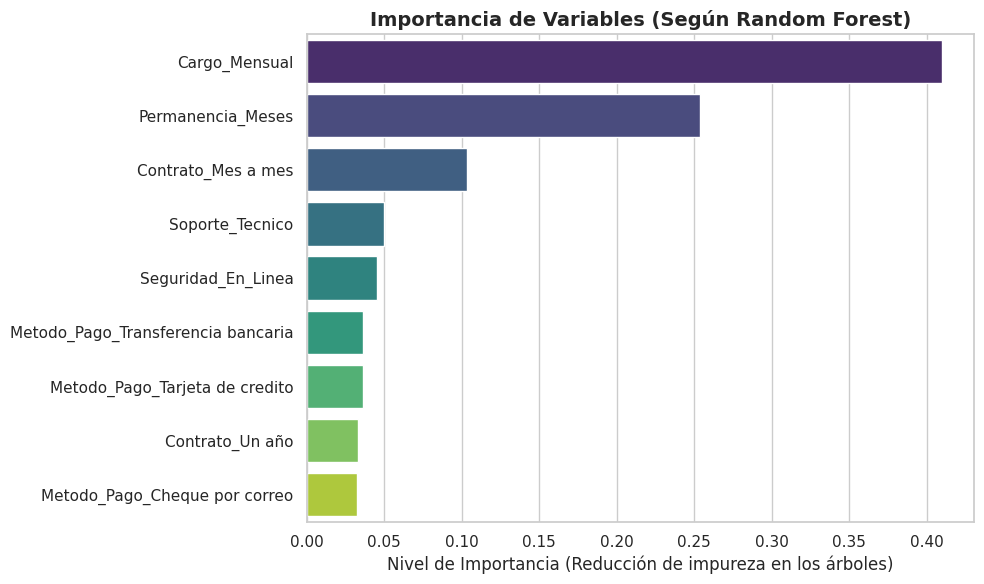

In [32]:


# ===================================================================
# IMPORTANCIA DE LAS VARIABLES (Según el Random Forest)
# ===================================================================
# Extraemos la importancia calculada por los árboles de decisión
importancia_rf = modelo_rf.feature_importances_
nombres_columnas_rf = X_train_bal_raw.columns

# Creamos un DataFrame para ordenarlo de mayor a menor importancia
df_importancia_rf = pd.DataFrame({'Variable': nombres_columnas_rf, 'Importancia': importancia_rf})
df_importancia_rf = df_importancia_rf.sort_values(by='Importancia', ascending=False)

# Dibujar el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia_rf,
            hue='Variable', palette='viridis', legend=False)

plt.title('Importancia de Variables (Según Random Forest)', fontsize=14, weight='bold')
plt.xlabel('Nivel de Importancia (Reducción de impureza en los árboles)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

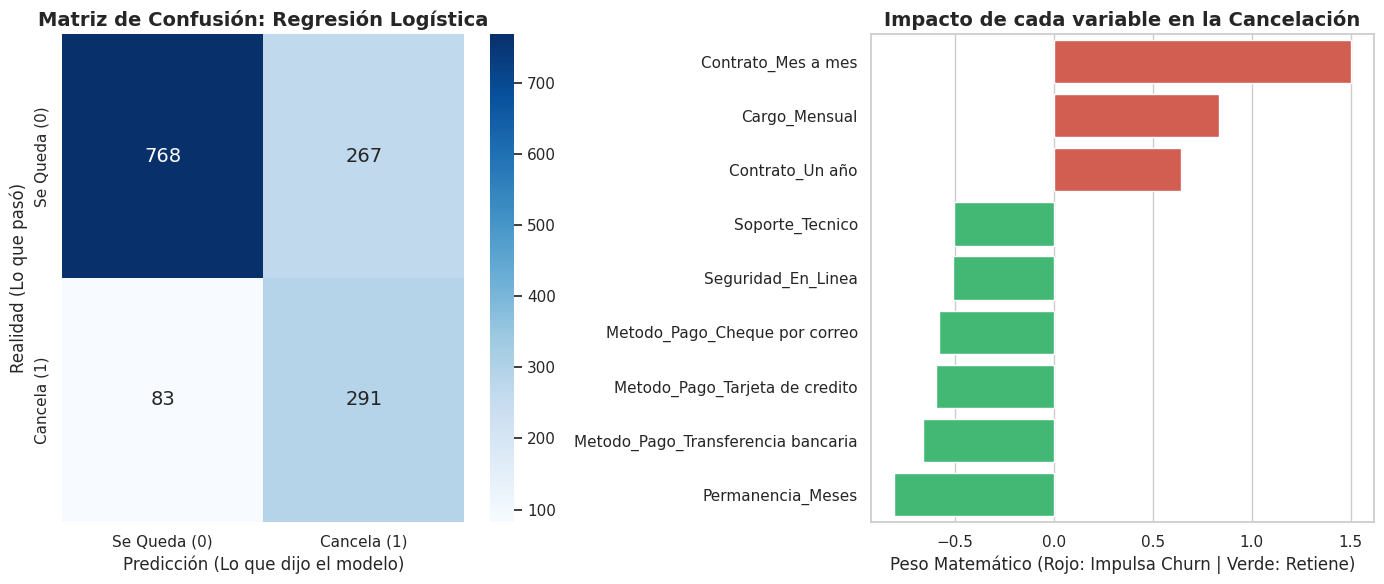

In [33]:


from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd # Asegurarnos de que pandas esté importado

# ===================================================================
# 1. MATRIZ DE CONFUSIÓN (Del modelo ganador: Regresión Logística)
# ===================================================================
matriz = confusion_matrix(y_test, y_pred_rl)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dibujar la matriz de confusión
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Se Queda (0)', 'Cancela (1)'],
            yticklabels=['Se Queda (0)', 'Cancela (1)'],
            annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusión: Regresión Logística', fontsize=14, weight='bold')
axes[0].set_ylabel('Realidad (Lo que pasó)', fontsize=12)
axes[0].set_xlabel('Predicción (Lo que dijo el modelo)', fontsize=12)

# ===================================================================
# 2. IMPORTANCIA DE LAS VARIABLES (Coeficientes de Regresión)
# ===================================================================
# Extraemos los coeficientes del modelo
importancia = modelo_rl.coef_[0]
nombres_columnas = X_train_bal_scaled.columns

# Creamos un DataFrame para ordenarlo
df_importancia = pd.DataFrame({'Variable': nombres_columnas, 'Peso': importancia})
df_importancia = df_importancia.sort_values(by='Peso', ascending=False)

# Convertimos la paleta de colores a una lista de Python para evitar la advertencia
colores_lista = np.where(df_importancia['Peso'] > 0, '#e74c3c', '#2ecc71').tolist()

# Dibujamos el gráfico de barras aplicando 'hue', 'legend=False' y la lista de colores
sns.barplot(x='Peso', y='Variable', data=df_importancia,
            hue='Variable', palette=colores_lista, legend=False, ax=axes[1])

axes[1].set_title('Impacto de cada variable en la Cancelación', fontsize=14, weight='bold')
axes[1].set_xlabel('Peso Matemático (Rojo: Impulsa Churn | Verde: Retiene)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Análisis Crítico y Evaluación de Modelos**


**1. Evaluación de Métricas Clave**
Basándonos en los reportes de clasificación generados en el conjunto de prueba (Test), obtenemos el siguiente panorama para nuestra clase objetivo (1: Cliente que cancela):

**Exactitud (Accuracy):** Ambos modelos empataron con un 75%. Sin embargo, debido al desbalance de clases, esta métrica es engañosa y no es suficiente para tomar una decisión de negocio.

**Precisión (Precision):** El Random Forest (0.54) superó ligeramente a la Regresión Logística (0.52). Esto significa que cuando el Random Forest predice que alguien se irá, tiene un poco más de certeza, pero a costa de ignorar a muchos otros.

**Sensibilidad (Recall):** La métrica más importante en este desafío. La Regresión Logística destrozó al Random Forest, logrando un 78% frente a un pobre 56%.

**F1-Score:** Al ser el punto de equilibrio entre Precisión y Recall, la Regresión Logística gana cómodamente con un 0.62 frente al 0.55 del Random Forest.


# **CONCLUSIÓN**


2. ¿Cuál modelo tuvo el mejor desempeño?
# 🏆**El modelo ganador definitivo es la Regresión Logística**

**Justificación Estratégica**: En un problema de Churn (Evasión), el error más costoso para la empresa es no detectar a un cliente que está a punto de irse (Falso Negativo).

Si usamos el Random Forest (Recall 56%), dejaremos ir al 44% de los clientes insatisfechos sin siquiera intentar retenerlos, lo que se traduce en una pérdida masiva de ingresos.

Al usar la Regresión Logística (Recall 78%), logramos "capturar" a casi 8 de cada 10 clientes en riesgo. Aunque esto signifique llamar a algunos clientes que en realidad no iban a cancelar (Falso Positivo por su precisión del 52%), el costo de una llamada telefónica o de un pequeño descuento es minúsculo comparado con perder la suscripción de un usuario para siempre.

**3. Análisis de Overfitting y Underfitting**
Al analizar el comportamiento de nuestros algoritmos, detectamos un fenómeno claro de Overfitting (Sobreajuste) en el modelo de Random Forest.

Diagnóstico del Random Forest (Overfitting):
Los Árboles de Decisión, por su naturaleza, tienden a memorizar el conjunto de datos de entrenamiento (creando ramas infinitas hasta clasificar perfectamente a cada individuo). Al no limitar su profundidad, el modelo aprendió demasiado bien los patrones específicos del grupo de entrenamiento, pero perdió la capacidad de generalizar cuando se enfrentó a los datos nuevos del conjunto de prueba, provocando que su Recall cayera drásticamente al 56%.



Diagnóstico de la Regresión Logística (Buen Ajuste / Generalización):
Por el contrario, la Regresión Logística es un modelo lineal mucho más rígido y simple. Su naturaleza matemática actúa como un regularizador natural que le impide memorizar el "ruido" de los datos. Esto le permitió capturar las tendencias generales (como el peso del contrato mes a mes y los cargos altos) y aplicarlas exitosamente a los datos de prueba, manteniendo un excelente equilibrio y logrando generalizar de forma robusta

# **Estrategias de retención basadas en los resultados obtenidos.**

📊 Reporte Final: Factores de Riesgo y Estrategias de Retención
Tras analizar el comportamiento de los clientes y evaluar la importancia de las variables utilizando nuestros modelos predictivos (Regresión Logística y Random Forest), hemos identificado los impulsores clave del Churn (Cancelación) y diseñado un plan de acción estratégico.

🚨 1. Principales Factores que Afectan la Cancelación
Al combinar la "visión" de ambos algoritmos, descubrimos que la cancelación no es aleatoria, sino que obedece a un patrón muy claro dictado por 4 factores principales:

El Tipo de Contrato (El factor #1): El modelo de Regresión Logística determinó que tener un contrato "Mes a Mes" es el riesgo más grande para la compañía. Al no tener barreras de salida, los clientes cancelan ante la menor insatisfacción.

La Barrera de los 10 Meses (Permanencia): El Random Forest nos demostró que el tiempo es crítico. La inmensa mayoría de las deserciones ocurren tempranamente, con una mediana de abandono en el mes 10. Si un cliente supera su primer año, su probabilidad de irse cae drásticamente.

El Costo Percibido (Cargo Mensual): Los clientes que cancelan pagan, en promedio, facturas más altas ($79 USD vs $64 USD de los retenidos). El Random Forest utiliza constantemente este valor alto para predecir fugas.

Carencia de Servicios Ancla: Los algoritmos le otorgan un "peso verde" (de retención) a variables como Soporte Técnico y Seguridad en Línea. Quienes no tienen estos servicios son altamente propensos a la evasión, ya que no sienten dependencia tecnológica con TelecomX.

💡 2. Estrategias de Retención Propuestas
Basándonos estrictamente en los datos obtenidos, proponemos al equipo de negocio implementar las siguientes 4 estrategias de retención:

Estrategia A: "Migración Incentivada" (Atacar el Contrato Mes a Mes)

Acción: Lanzar una campaña dirigida a los clientes de "Mes a mes" ofreciéndoles un descuento del 10% en su Cargo Mensual o una mejora de velocidad de internet si firman un contrato de "Un año".

Por qué funciona: Reducimos la factura (atacando el factor de costo) y amarramos al cliente a largo plazo, anulando el principal factor de riesgo.

Estrategia B: "Plan de Acompañamiento Temprano" (Atacar la Barrera de los 10 meses)

Acción: Crear un programa de fidelidad durante los primeros 12 meses. Por ejemplo, ofrecer beneficios progresivos en el mes 3, 6 y 9 (como canales premium gratis por un mes).

Por qué funciona: Mantiene al cliente motivado y comprometido justo en la "zona de peligro" donde sabemos que estadísticamente suelen cancelar.

Estrategia C: "Freemium de Servicios Ancla"

Acción: Regalar 3 meses de Soporte Técnico y Seguridad en Línea a todos los clientes nuevos.

Por qué funciona: Genera un hábito de uso. Cuando el periodo de prueba termine, muchos preferirán pagar un extra para no perder la protección, aumentando tanto la retención como el ingreso por cliente.

Estrategia D: "Fricción Cero en Pagos"

Acción: Bonificar con un pequeño saldo a favor a los usuarios que cambien su método de pago de "Cheque Electrónico" a "Tarjeta de Crédito (Automático)".

Por qué funciona: Evita que el cliente tenga que tomar la decisión consciente de pagar todos los meses, reduciendo la fricción y el dolor de desprenderse de su dinero.

In [34]:
# Para subir este notebook a GitHub, por favor, descárgalo como un archivo .ipynb
# desde el menú 'Archivo' -> 'Descargar' -> 'Descargar .ipynb'.
# Luego, puedes subirlo a tu repositorio de GitHub.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Cargar y codificar datos
df = pd.read_csv('TelecomX_Simplified_Data.csv')
if 'Cuentas_Diarias' in df.columns:
    df = df.drop(columns=['Cuentas_Diarias'])
df_ml = pd.get_dummies(df, columns=['Contrato', 'Metodo_Pago'], dtype=int, drop_first=True)

X = df_ml.drop(columns=['Evasion'])
y = df_ml['Evasion']

# 2. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. NORMALIZACIÓN (Para la Regresión Logística)
scaler = StandardScaler()
cols_num = ['Permanencia_Meses', 'Cargo_Mensual']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test_scaled[cols_num] = scaler.transform(X_test[cols_num])

# 4. BALANCEO (SMOTE) para ambos escenarios
smote = SMOTE(random_state=42)
X_train_bal_scaled, y_train_bal = smote.fit_resample(X_train_scaled, y_train) # Para Regresión
X_train_bal_raw, _ = smote.fit_resample(X_train, y_train)                     # Para Random Forest

print("✅ Datos preparados, escalados y balanceados correctamente.")

✅ Datos preparados, escalados y balanceados correctamente.
